In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from datasets import load_dataset
import re
import random
from tensorflow import keras
import matplotlib.pyplot as plt

In [ ]:
# Reproducibility: set global seeds
import os
import random
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


In [ ]:
df = pd.read_csv("ranking_dataset.csv")
print(df.head())

   val_0  val_1  val_2  val_3  val_4  val_5  val_6  val_7  val_8  val_9  \
0    542     67    876    414     26    335    620    924    950    113   
1    378     14    210    954    231    572    315    295    567    706   
2    749    876     73    111    899    213    541    769    287    219   
3    372    880    475    329    733    564    739    376    632     10   
4    186    822    577    519    707    123    143    294    693    677   

   rank_0  rank_1  rank_2  rank_3  rank_4  rank_5  rank_6  rank_7  rank_8  \
0       5       1       7       4       0       3       6       8       9   
1       5       0       1       9       2       7       4       3       6   
2       6       8       0       1       9       2       5       7       4   
3       2       9       4       1       7       5       8       3       6   
4       2       9       5       4       8       0       1       3       7   

   rank_9  
0       2  
1       8  
2       3  
3       0  
4       6  


In [ ]:
len(df)

10000

In [ ]:
pairs = []
for i in range(len(df)):
  vals = []
  ranks = []
  for j in range(10):
    vals.append(df.iloc[i, j])
  for k in range(10, 20):
    ranks.append(df.iloc[i, k])
  pairs.append((vals, ranks))

print(pairs[0])

([np.int64(542), np.int64(67), np.int64(876), np.int64(414), np.int64(26), np.int64(335), np.int64(620), np.int64(924), np.int64(950), np.int64(113)], [np.int64(5), np.int64(1), np.int64(7), np.int64(4), np.int64(0), np.int64(3), np.int64(6), np.int64(8), np.int64(9), np.int64(2)])


In [ ]:
train = pairs[:7000]
eval = pairs[7000:8500]
test = pairs[8500:]

In [ ]:
def batches(pairs, batch_size):
    #random.shuffle(pairs)
    for i in range(0, len(pairs) - batch_size + 1, batch_size):

        batch = pairs[i: i + batch_size]

        inputs = []
        targets = []

        for i in batch:
            inputs.append(i[0])
            targets.append(i[1])

        yield tf.constant(inputs, dtype=tf.int32), tf.constant(targets, dtype=tf.int32)



#[([],[]),([],[]),([],[])]
#([],[])

In [ ]:
#X, y = batches(pairs, 5)
#X = tf.expand_dims(X, -1)

print(type(batches(pairs, 5)))
#print(len(batches(pairs, 5)))

#print(X[0])

<class 'generator'>


In [ ]:
%pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


MLP

In [ ]:
batchsize = 100
d_model = 256
EPOCHS = 30
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
mlp = keras.Sequential([keras.layers.Input(shape=(10,1)),
keras.layers.Dense(d_model, activation= 'relu'),
keras.layers.Dense(d_model, activation= 'relu'),
keras.layers.Dropout(0.3),
keras.layers.Dense(10, activation='softmax')])


In [ ]:
import evaluate

losstrack = []
acctrack = []

# Checkpointing setup for MLP
ckpt = tf.train.Checkpoint(optimizer=optimizer, model=mlp)
ckpt_manager = tf.train.CheckpointManager(ckpt, './checkpoints/mlp', max_to_keep=5)
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    print('Restored MLP from', ckpt_manager.latest_checkpoint)

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    #training

    train_loss, steps = 0, 0
    for Xtrain, ytrain in batches(train, batchsize):
        with tf.GradientTape() as tape:
            predictions = mlp(Xtrain, training=True)
            loss = loss_fn(ytrain, predictions)
        grads = tape.gradient(loss, mlp.trainable_variables)
        optimizer.apply_gradients(zip(grads, mlp.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    losstrack.append(train_loss/steps)

    #validation

    for Xval, yval in batches(eval, batchsize):
        predictions = mlp(Xval, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = yval.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}%")

    # save checkpoint at end of epoch
    ckpt_manager.save()



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Epoch 01/30  Loss: 9.7146  Val Acc: 13.97%
Epoch 02/30  Loss: 2.2015  Val Acc: 15.35%
Epoch 03/30  Loss: 2.1652  Val Acc: 17.52%
Epoch 04/30  Loss: 2.1360  Val Acc: 18.29%
Epoch 05/30  Loss: 2.1902  Val Acc: 23.01%
Epoch 06/30  Loss: 2.1588  Val Acc: 22.05%
Epoch 07/30  Loss: 2.1158  Val Acc: 22.69%
Epoch 08/30  Loss: 2.1063  Val Acc: 23.64%
Epoch 09/30  Loss: 2.0658  Val Acc: 27.36%
Epoch 10/30  Loss: 2.0073  Val Acc: 25.97%
Epoch 11/30  Loss: 1.9938  Val Acc: 28.73%
Epoch 12/30  Loss: 2.0015  Val Acc: 28.59%
Epoch 13/30  Loss: 1.9469  Val Acc: 27.77%
Epoch 14/30  Loss: 1.9270  Val Acc: 29.59%
Epoch 15/30  Loss: 1.9461  Val Acc: 30.09%
Epoch 16/30  Loss: 1.9089  Val Acc: 30.85%
Epoch 17/30  Loss: 1.8880  Val Acc: 24.95%
Epoch 18/30  Loss: 1.9037  Val Acc: 31.02%
Epoch 19/30  Loss: 1.8549  Val Acc: 32.51%
Epoch 20/30  Loss: 1.8563  Val Acc: 32.41%
Epoch 21/30  Loss: 1.8361  Val Acc: 34.09%
Epoch 22/30  Loss: 1.8291  Val Acc: 32.51%
Epoch 23/30  Loss: 1.8101  Val Acc: 34.84%
Epoch 24/30

In [ ]:
# Save MLP weights
import os
os.makedirs('./checkpoints/mlp', exist_ok=True)
mlp.save_weights('./checkpoints/mlp/mlp_weights')

mlp.save('./saved_models/mlp_full')


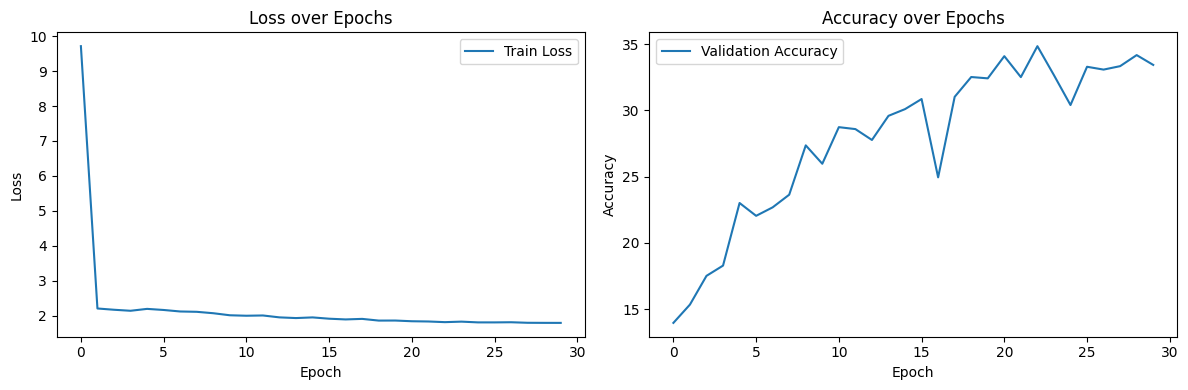

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#testing

for Xtest, ytest in batches(test, batchsize):
        predictions = mlp(Xtest, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = ytest.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

test_acc = accuracy_metric.compute()["accuracy"] * 100
print(f"\nTest Acc: {test_acc:.2f}%")


Test Acc: 33.94%


RNN

In [ ]:
batchsize = 100
d_model = 128
EPOCHS = 15
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
rnn = keras.Sequential([keras.layers.Input(shape=(10,1)),
keras.layers.Dense(d_model),
keras.layers.SimpleRNN(d_model, return_sequences=True),
keras.layers.Dropout(0.4),
keras.layers.Dense(10)])


In [ ]:
import evaluate

losstrack = []
acctrack = []

# Checkpointing setup for RNN
ckpt = tf.train.Checkpoint(optimizer=optimizer, model=rnn)
ckpt_manager = tf.train.CheckpointManager(ckpt, './checkpoints/rnn', max_to_keep=5)
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    print('Restored RNN from', ckpt_manager.latest_checkpoint)

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    #training

    train_loss, steps = 0, 0
    for Xtrain, ytrain in batches(train, batchsize):
        with tf.GradientTape() as tape:
            predictions = rnn(Xtrain, training=True)
            loss = loss_fn(ytrain, predictions)
        grads = tape.gradient(loss, rnn.trainable_variables)
        optimizer.apply_gradients(zip(grads, rnn.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    losstrack.append(train_loss/steps)

    #validation

    for Xval, yval in batches(eval, batchsize):
        predictions = rnn(Xval, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = yval.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}%")

    # save checkpoint at end of epoch
    ckpt_manager.save()



Epoch 01/15  Loss: 2.5413  Val Acc: 27.55%
Epoch 02/15  Loss: 2.2521  Val Acc: 26.53%
Epoch 03/15  Loss: 2.0960  Val Acc: 28.66%
Epoch 04/15  Loss: 1.9754  Val Acc: 30.31%
Epoch 05/15  Loss: 1.8964  Val Acc: 25.99%
Epoch 06/15  Loss: 1.8987  Val Acc: 30.63%
Epoch 07/15  Loss: 1.8476  Val Acc: 29.79%
Epoch 08/15  Loss: 1.8088  Val Acc: 33.47%
Epoch 09/15  Loss: 1.7880  Val Acc: 32.45%
Epoch 10/15  Loss: 1.7888  Val Acc: 30.95%
Epoch 11/15  Loss: 1.7864  Val Acc: 32.12%
Epoch 12/15  Loss: 1.7658  Val Acc: 33.25%
Epoch 13/15  Loss: 1.7712  Val Acc: 33.83%
Epoch 14/15  Loss: 1.7458  Val Acc: 33.26%
Epoch 15/15  Loss: 1.7472  Val Acc: 34.76%


In [ ]:
# Save RNN weights
import os
os.makedirs('./checkpoints/rnn', exist_ok=True)
rnn.save_weights('./checkpoints/rnn/rnn_weights')

rnn.save('./saved_models/rnn_full')


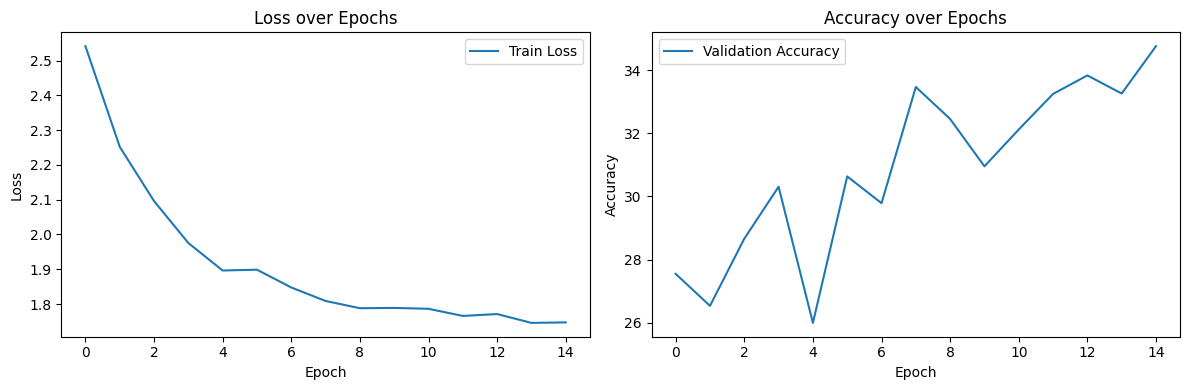

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#testing

for Xtest, ytest in batches(test, batchsize):
        predictions = rnn(Xtest, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = ytest.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

test_acc = accuracy_metric.compute()["accuracy"] * 100
print(f"\nTest Acc: {test_acc:.2f}%")


Test Acc: 35.01%


LSTM

In [ ]:
batchsize = 100
d_model = 128
EPOCHS = 25
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

In [ ]:
lstm = keras.Sequential([keras.layers.Input(shape=(10,1)),
keras.layers.Dense(d_model),
keras.layers.LSTM(d_model, return_sequences=True),
keras.layers.Dropout(0.3),
keras.layers.LSTM(d_model, return_sequences=True),
keras.layers.Dropout(0.4),
keras.layers.Dense(10, activation = 'softmax')])

In [ ]:
import evaluate

losstrack = []
acctrack = []

# Checkpointing setup for LSTM
ckpt = tf.train.Checkpoint(optimizer=optimizer, model=lstm)
ckpt_manager = tf.train.CheckpointManager(ckpt, './checkpoints/lstm', max_to_keep=5)
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    print('Restored LSTM from', ckpt_manager.latest_checkpoint)

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    #training

    train_loss, steps = 0, 0
    for Xtrain, ytrain in batches(train, batchsize):
        with tf.GradientTape() as tape:
            predictions = lstm(Xtrain, training=True)
            loss = loss_fn(ytrain, predictions)
        grads = tape.gradient(loss, lstm.trainable_variables)
        optimizer.apply_gradients(zip(grads, lstm.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    losstrack.append(train_loss/steps)

    #validation

    for Xval, yval in batches(eval, batchsize):
        predictions = lstm(Xval, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = yval.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}%")

    # save checkpoint at end of epoch
    ckpt_manager.save()



Epoch 01/25  Loss: 2.2778  Val Acc: 20.59%
Epoch 02/25  Loss: 2.1382  Val Acc: 24.09%
Epoch 03/25  Loss: 1.9348  Val Acc: 29.08%
Epoch 04/25  Loss: 1.7930  Val Acc: 33.01%
Epoch 05/25  Loss: 1.7029  Val Acc: 36.01%
Epoch 06/25  Loss: 1.6397  Val Acc: 37.95%
Epoch 07/25  Loss: 1.5969  Val Acc: 39.47%
Epoch 08/25  Loss: 1.5668  Val Acc: 40.71%
Epoch 09/25  Loss: 1.5392  Val Acc: 41.53%
Epoch 10/25  Loss: 1.5136  Val Acc: 42.48%
Epoch 11/25  Loss: 1.4959  Val Acc: 42.36%
Epoch 12/25  Loss: 1.4843  Val Acc: 42.76%
Epoch 13/25  Loss: 1.4671  Val Acc: 43.38%
Epoch 14/25  Loss: 1.4559  Val Acc: 44.01%
Epoch 15/25  Loss: 1.4443  Val Acc: 43.79%
Epoch 16/25  Loss: 1.4331  Val Acc: 43.85%
Epoch 17/25  Loss: 1.4244  Val Acc: 44.47%
Epoch 18/25  Loss: 1.4193  Val Acc: 44.35%
Epoch 19/25  Loss: 1.4104  Val Acc: 44.61%
Epoch 20/25  Loss: 1.4004  Val Acc: 45.40%
Epoch 21/25  Loss: 1.3979  Val Acc: 45.31%
Epoch 22/25  Loss: 1.3942  Val Acc: 45.49%
Epoch 23/25  Loss: 1.3884  Val Acc: 45.75%
Epoch 24/25

In [ ]:
# Save LSTM weights
import os
os.makedirs('./checkpoints/lstm', exist_ok=True)
lstm.save_weights('./checkpoints/lstm/lstm_weights')

lstm.save('./saved_models/lstm_full')


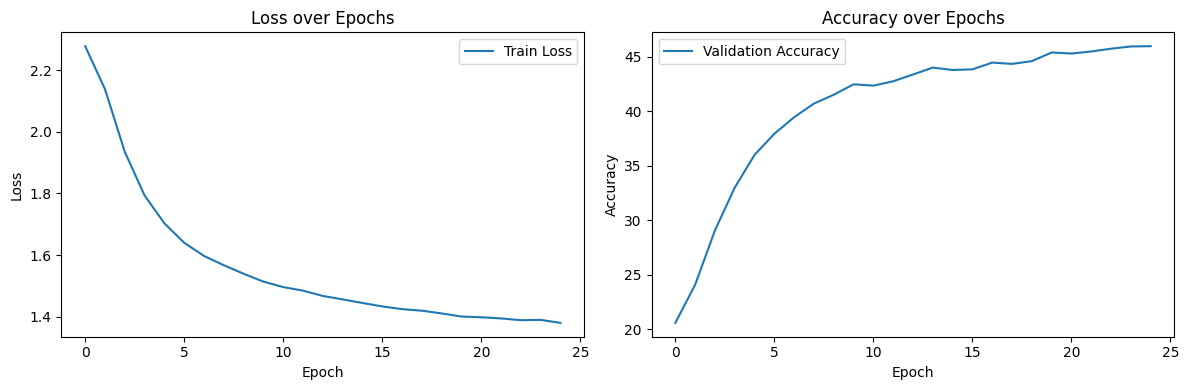

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#testing

for Xtest, ytest in batches(test, batchsize):
        predictions = lstm(Xtest, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = ytest.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

test_acc = accuracy_metric.compute()["accuracy"] * 100
print(f"\nTest Acc: {test_acc:.2f}%")


Test Acc: 45.72%
